# 03 — Model B: Fraud Detection

Detect return fraud using LightGBM with graph features from the
customer-address / customer-payment network.

**Key design choice**: graph features (shared address count, component size)
are the primary signal for ring fraud — individual behavioural features alone
cannot detect it.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[2] / "src"))  # commerce-ml-lab/src  (shared lib)
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))  # 02_returns_intelligence/src
import warnings

warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from commerce_ml.viz.plotting import apply_style, PALETTE
from returns.fraud import FraudDetectionModel, build_graph_features
from commerce_ml.evaluation.classification_metrics import (
    pr_auc,
    precision_at_k,
    cost_aware_threshold,
)

apply_style()
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

customers = pd.read_parquet(RESULTS / "customers.parquet")
orders = pd.read_parquet(RESULTS / "orders.parquet")
returns = pd.read_parquet(RESULTS / "returns.parquet")
print(f"Returns: {len(returns):,}  |  Fraud rate: {returns['is_fraud'].mean():.2%}")

Returns: 10,476  |  Fraud rate: 3.86%


In [2]:
# Train/test split on returns (temporal)
returns_sorted = returns.sort_values("return_date")
split_idx = int(len(returns_sorted) * 0.80)
train_ret = returns_sorted.iloc[:split_idx]
test_ret = returns_sorted.iloc[split_idx:]
print(f"Train: {len(train_ret):,}  |  Test: {len(test_ret):,}")

Train: 8,380  |  Test: 2,096


## Build graph features

In [3]:
train_g = build_graph_features(train_ret, customers)
test_g = build_graph_features(test_ret, customers)

print("Graph features on test set:")
print(
    test_g[["shared_address_count", "shared_payment_count", "component_size"]].describe().round(2)
)
ring_test = test_g.merge(customers[["customer_id", "archetype"]], on="customer_id")
print("\nComponent size by archetype:")
print(ring_test.groupby("archetype")["component_size"].mean().sort_values(ascending=False).round(1))

Graph features on test set:
       shared_address_count  shared_payment_count  component_size
count               2096.00               2096.00         2096.00
mean                   0.09                  0.09            1.09
std                    1.02                  1.02            1.02
min                    0.00                  0.00            1.00
25%                    0.00                  0.00            1.00
50%                    0.00                  0.00            1.00
75%                    0.00                  0.00            1.00
max                   15.00                 15.00           16.00

Component size by archetype:
archetype
ring         11.2
normal        1.0
wardrober     1.0
Name: component_size, dtype: float64


## Train the fraud model

In [4]:
model = FraudDetectionModel()
model.fit(train_ret, orders, customers, auto_threshold=True)
print(f"Cost-optimal threshold: {model.threshold_:.3f}")
print(f"FP cost: {model.fp_cost}  |  FN cost: {model.fn_cost}")

Cost-optimal threshold: 0.074
FP cost: 5.0  |  FN cost: 50.0


## Evaluate: PR-AUC, precision@K, confusion matrix

In [5]:
from sklearn.metrics import classification_report

preds = model.predict(test_ret, orders, customers)
y_true = test_ret["is_fraud"].astype(int).values
y_score = preds["fraud_probability"].values
y_pred = preds["is_flagged"].astype(int).values

prauc = pr_auc(y_true, y_score)
p_at_100 = precision_at_k(y_true, y_score, k=100)

print(f"PR-AUC:           {prauc:.4f}  (random={y_true.mean():.4f})")
print(f"Precision@100:    {p_at_100:.1%}  (fraction of top-100 flags that are truly fraud)")
print(f"\nClassification report at threshold={model.threshold_:.2f}:")
print(classification_report(y_true, y_pred, target_names=["Honest", "Fraud"], zero_division=0))

PR-AUC:           0.5601  (random=0.0239)
Precision@100:    39.0%  (fraction of top-100 flags that are truly fraud)

Classification report at threshold=0.07:
              precision    recall  f1-score   support

      Honest       0.99      0.97      0.98      2046
       Fraud       0.39      0.78      0.52        50

    accuracy                           0.97      2096
   macro avg       0.69      0.88      0.75      2096
weighted avg       0.98      0.97      0.97      2096



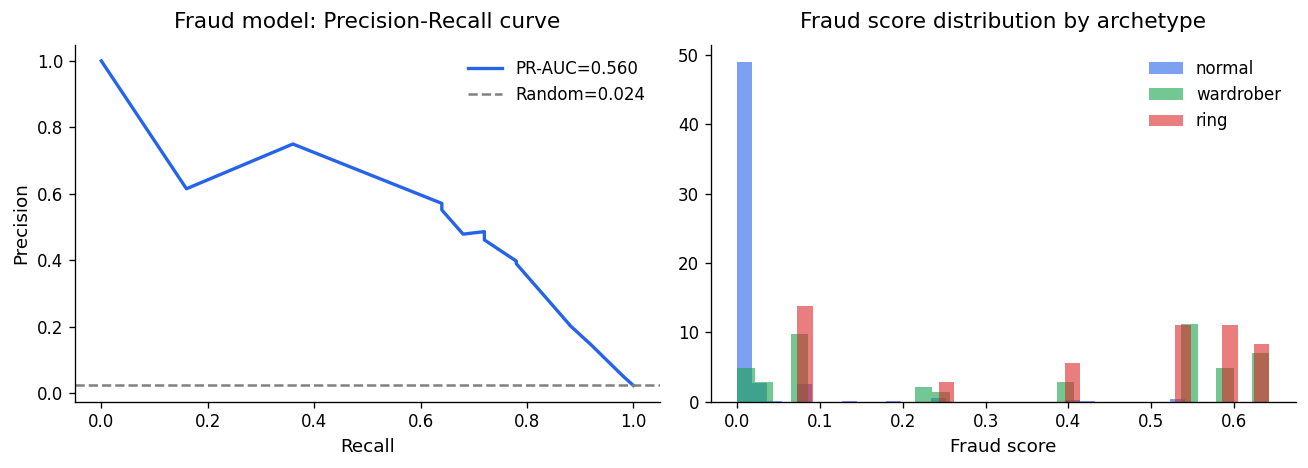

In [6]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

prec, rec, _ = precision_recall_curve(y_true, y_score)
axes[0].plot(rec, prec, color=PALETTE[0], linewidth=2, label=f"PR-AUC={prauc:.3f}")
axes[0].axhline(y_true.mean(), color="grey", linestyle="--", label=f"Random={y_true.mean():.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Fraud model: Precision-Recall curve")
axes[0].legend()

# Fraud score by archetype
test_arch = test_ret.merge(customers[["customer_id", "archetype"]], on="customer_id")
test_arch["fraud_score"] = y_score
for arch in ["normal", "wardrober", "velocity", "ring"]:
    sub = test_arch[test_arch["archetype"] == arch]["fraud_score"]
    if len(sub) > 0:
        axes[1].hist(sub, bins=30, alpha=0.6, label=arch, density=True)
axes[1].set_xlabel("Fraud score")
axes[1].set_title("Fraud score distribution by archetype")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / "fraud_evaluation.png", dpi=120)
plt.show()

In [7]:
# Top reason codes for flagged returns
flagged = preds[preds["is_flagged"]]
print(
    f"Flagged returns: {len(flagged):,}  |  Precision: {(y_true[preds['is_flagged'].values] == 1).mean():.1%}"
)
print("\nTop reason codes for flagged returns:")
print(flagged["top_reason_1"].value_counts().head(8))

model.save(RESULTS / "fraud_model.pkl")
print("\nModel saved to results/fraud_model.pkl")

Flagged returns: 100  |  Precision: 39.0%

Top reason codes for flagged returns:
top_reason_1
days_to_return                   38
customer_total_returns           22
is_used_condition                18
shared_address_count             14
customer_lifetime_return_rate     4
item_price                        2
is_damaged_condition              1
customer_total_orders             1
Name: count, dtype: int64

Model saved to results/fraud_model.pkl
